<h1 style="text-align: center; vertical-align: middle;">S35 Accelerator & Detector Physics</h1>
<h2 style="text-align: center; vertical-align: middle;">Accelerator Physics by Professor Adrian Oeftiger</h2>

<div style="width: 45%; margin: auto; margin-top: 1em; padding-bottom: 1em; vertical-align: middle;">
<img src="./img/University_of_Oxford_logo.png" style="width: 40%; float: left; margin-right: 5%;" /><img src="./img/jai-logo.png" style="width: 50%; float: left; margin-right: 5%; margin-top:0;" />
</div>

<h3 style="clear: both; text-align: center; margin-top: 3em;">Lecture 4: Magnets and Focusing</h3>

<h2>Run this notebook online!</h2>

Interact and run this jupyter notebook online:

<div class="alert alert-block alert-info" style="text-align:center;">
via the local Physics Jupyterlab service: <br />
<a href="https://jupyterlab.physics.ox.ac.uk" style="width:auto; display:table;margin:0.5em auto;"><img src="https://shields.io/badge/JupyterLab-Department%20of%20Physics-F37626?logo=jupyter" alt="physics department logo" style="height: 1.3em;" /></a>
</div>

<div class="alert alert-block alert-info" style="text-align:center;">
via the public mybinder.org service: <br />
<a href="https://mybinder.org/v2/gh/aoeftiger/UOXF-AP-2026/v4.0" style="width:auto; display:table;margin:0.5em auto;"><img src="./img/binder_logo.svg" alt="mybinder.org logo" style="height: 1.3em;" /></a>
</div>

Also find this lecture rendered [as HTML slides on github $\nearrow$](https://aoeftiger.github.io/UOXF-AP-2026/) along with the [source repository $\nearrow$](https://github.com/aoeftiger/UOXF-AP-2026).

<h2>Run this first!</h2>

Imports and modules:

In [1]:
from config import (np, plt, plot_Efield_vs_Ekin, 
                    plot_quadfield, plot_sextfield)
from scipy.constants import m_p, e, c
%matplotlib inline

<h2 style="color: #b51f2a">Refresher!</h2>


- beam rigidity equation: $B\rho=p/|q|$
- synchrotron principle, $f_\text{rf}=h\cdot f_\text{rev}$ with harmonic $h\in\mathbb{N}$
- momentum compaction $\alpha_c$ due to path length change with momentum
- phase-slip factor $\eta=\gamma_t^{-2}-\gamma^{-2}$
- transition energy $\gamma_t$
- longitudinal particle tracking equations for synchrotrons
- Hamiltonian landscape for synchrotron motion
- simulation of acceleration ramp, incl. transition crossing: <br />"classical" vs. "relativistic" regime and $\varphi_s\mapsto\pi-\varphi_s$ synchronous phase adjustment

<h2 style="color: #b51f2a">Today!</h2>

1. Magnetic Fields: Dipoles, Quadrupoles, Sextupoles
2. Linear Transverse Beam Dynamics & Betatron Transfer Matrices
3. Simulations of Betatron Motion

<div style="text-align: center; width:100%;">
    <h2>Part I: Magnetic Fields: Dipoles, Quadrupoles, Sextupoles</h2>
</div>

<h2>Magnetic or Electric Fields</h2>

The motion of a charged particle in an electric or magnetic field is described by the Lorentz force:

$$\mathbf{F}_L=q(\mathbf{E} + \mathbf{v}\times \mathbf{B})$$

To achieve the same deflection, a 1 T magnetic field corresponds to an equivalent electric field of...

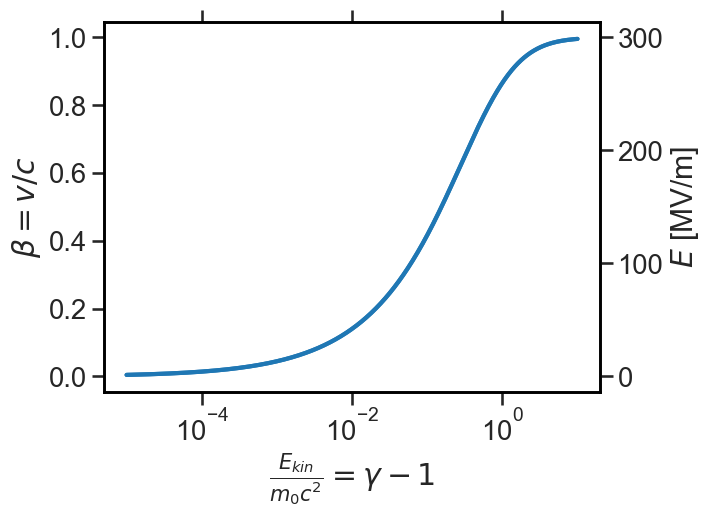

In [2]:
plot_Efield_vs_Ekin();

Electrons have a rest mass of $m_0c^2\approx 511$ keV and protons of $m_0c^2\approx 938$ MeV. 

<p style="color: #e6541a;">$\leadsto$ Consider an $E$-field of 100 MV/m. At what (low) kinetic energy is a 1 T $B$-field equivalent to this (very high) $E$-field in terms of the Lorentz force? Compare this energy to the energies reached in the accelerator facilities discussed in <a href="https://aoeftiger.github.io/UOXF-AP-2026/lecture1/lecture.slides.html#/15">Lecture 1</a>!</p>

<h2>Maxwell Equations: Magnetostatics</h2>

$$\left\{\begin{array}\,
    \nabla \cdot \mathbf{E} &=& \frac{\rho}{\epsilon_0} \\
    \nabla \times \mathbf{E} + \frac{\partial\mathbf{B}}{\partial t} &=& \mathbf{0} \\
    \nabla \cdot \mathbf{B} &=& 0 \\
    \nabla \times \mathbf{B} - \frac{1}{c^2} \frac{\partial\mathbf{E}}{\partial t} &=&  \mu_0 \mathbf{j}
\end{array}\right.$$

Constant (or adiabatically changing) magnetic fields at beam location *in vacuum* determined by: 

$$\mathbf{j}=0\quad\text{and}\quad\frac{\partial\mathbf{E}}{\partial t}=0\implies\text{magnetostatics: }\left\{\begin{array}\,\nabla\cdot \mathbf{B} &= 0 \\
    \nabla \times \mathbf{B}&=0\end{array}\right.$$

<img src="./img/frenet-serret.png" alt="Frenet Serret coordinate system" style="width:30%; float:right; margin-left:1em; margin-top:2em;" />

<h2>Revisited: Beam Rigidity and Circular Orbit</h2>

From $F_\text{centrip} = F_\text{L}$, obtained *beam rigidity* expression $B\rho=p/|q|$ in <a href="https://aoeftiger.github.io/UOXF-AP-2026/lecture3/lecture.slides.html#/6">Lecture 3</a>.

In practical units:

<div class="alert alert-block alert-success" style="text-align: center;">
$$p~[\mathrm{GeV}/c]=0.3\,B~[\mathrm{T}]\cdot\rho~[\mathrm{m}]$$
</div>

$\implies$ For a circular accelerator or storage ring, use dipole fields $B_y$ to create horizontal **closed circular orbit**. Typically achieve a dipole filling factor of up to 2/3 of the ring circumference.

<span style="color: #e6541a;">$\leadsto$ The 27 km long LHC ring consists of 1232 dipole magnets. What approximate field strength $B_y$ do they provide to maintain this circular orbit at the maximum beam momentum of 7 TeV/$c$?</span>

<h2>Multipole Expansion / Beth Representation</h2>

Transverse magnetic fields $B_{x,y}$ can be expanded in a **multipole series**, also known as **Beth representation**:

$$B_x + iB_y = B_0 \sum\limits_{n=1}^\infty (b_n + ia_n)\cdot (x+iy)^{n-1}$$

The $b_n,a_n$ are the multipole coefficients for normal and skew field components, respectively, and $B_0$ refers to the reference (*dipole*) field.

$$\begin{align}\,
n=1&\text{: dipole} \\
n=2&\text{: quadrupole} \\
n=3&\text{: sextupole} \\
n=4&\text{: octupole} \\
&...
\end{align}$$

"Skew" refers to a rotation of the field pattern by half a symmetry period. Consider e.g. a dipole, which has a 180 deg symmetry: a normal dipole with a vertical upright field becomes a skew dipole with a horizontal field (rotated by 180 deg/2 = 90 deg). A skew quadrupole is correspondingly rotated by 45 deg, a skew sextupole by 30 deg, etc.

In the following, consider simplified case in the $y=0$ magnetic "*mid-plane*": $B_x$ terms disappear and $x\cdot y$ cross-terms vanish.

The $B_y$-field can be Taylor-expanded around *reference orbit* as

$$\cfrac{B_y}{B\rho} = \underbrace{\phantom{\biggl|}\frac{1}{\rho_0}}\limits_\text{dipole} + \underbrace{\phantom{\biggl|}k\cdot x}\limits_\text{quadrupole} + \underbrace{\phantom{\biggl|}\frac{1}{2!} m x^2}\limits_\text{sextupole} + \underbrace{\phantom{\biggl|}\frac{1}{3!} r x^3}\limits_\text{octupole} + \cdots $$

with the beam rigidity $B\rho=\frac{p}{|q|}$.

<h2>Dipole Fields</h2>

Const. field in vertical direction $y$ with $b_1=1$ for the main dipoles.

<h2>Quadrupole Fields</h2>

Quadrupoles provide focusing gradient $G$ for transverse planes.

Main quadrupole magnets are centred on reference orbit such that $B_{y,x}(x=y=0)=0$.

Normal quadrupole field: $\mathbf{B}=\underbrace{B_0\cdot b_2}\limits_{\mathop{\doteq}-G} \cdot \begin{pmatrix} y \\ x \\ 0 \end{pmatrix}$

Skew quadrupole field: $\mathbf{B}=B_0\cdot a_2 \cdot \begin{pmatrix} x \\ -y \\ 0 \end{pmatrix}$

<span style="color: #e6541a;">$\leadsto$ Verify that $\nabla\times \mathbf{B}=0$.

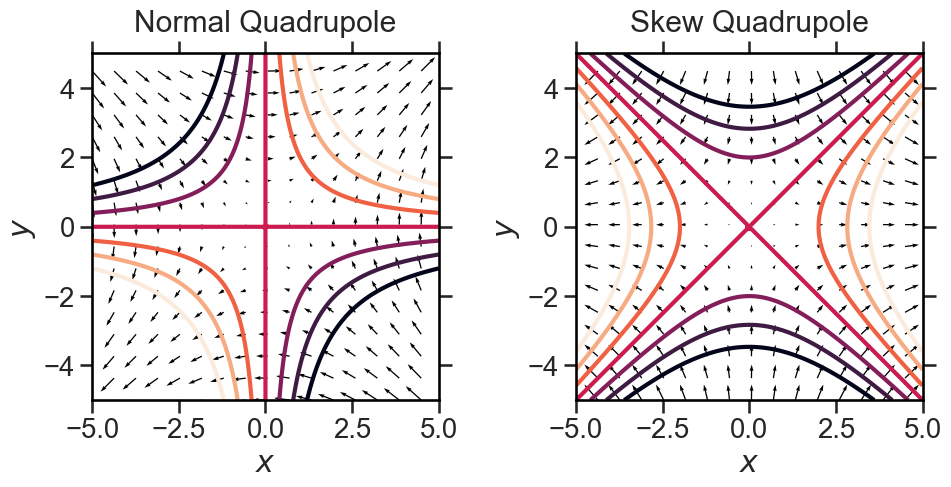

In [3]:
plot_quadfield()

<h2>Sextupole Fields</h2>

Usage: correct chromatic aberration of quadrupoles (dependency on particle's $\delta$, cf. Lecture 6).

Normal sextupole field: $\mathbf{B}=B_0\cdot b_3 \cdot \begin{pmatrix} 2xy \\ x^2-y^2 \\ 0 \end{pmatrix} \quad\implies $ non-linear dynamics!

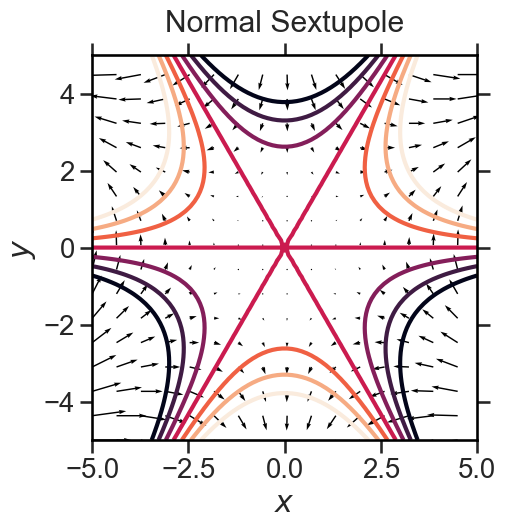

In [4]:
plot_sextfield()

<div style="text-align: center; width:100%;">
    <h2>Part II: Linear Transverse Beam Dynamics <br />& Betatron Transfer Matrices</h2>
</div>

<h2>Transverse Equations of Motion</h2>

Starting from the Lorentz force,

<center style="margin-top:1em;">
$\cfrac{d\mathbf{p}}{dt}=q\cdot \mathbf{v}\times\mathbf{B}\quad$ with $\quad \mathbf{p}=\gamma m_0\mathbf{v}\quad ,$
</center>

and applying the *paraxial approximation*, $v_z\approx |\mathbf{v}|=\beta c$ as well as $v_x,v_y\ll |\mathbf{v}|$, we find:

$$\implies\left\{\begin{array}\,\gamma m_0\cfrac{d^2x}{dt^2}&=&-q\cdot v_z\cdot B_y\\ \gamma m_0\cfrac{d^2y}{dt^2}&=&+q\cdot v_z\cdot B_x\end{array}\right.$$

Since $\cfrac{d}{dt}=\cfrac{ds}{dt}\,\cfrac{d}{ds}\approx \beta c\cfrac{d}{ds}$, and replacing the beam rigidity expression $p/|q|=B\rho$, the **equations of motion** for particles in transverse magnetic fields yield

$$\implies \left\{\begin{matrix}
    \cfrac{d^2x}{ds^2} + \cfrac{B_y}{B\rho} = 0 \\
    \cfrac{d^2y}{ds^2} - \cfrac{B_x}{B\rho} = 0
\end{matrix}\right.$$

As long as $B_{y,x}$ depend at max. linearly on $x,y$, these ordinary differential equations are <b>linear</b>.

In a **drift space**, where $\textbf{B}=0$, particles undergo uniform motion, and the transverse coordinates follow straight lines according to their transverse momenta $x'\doteq dx/ds$ and $y'\doteq dy/ds$:

$$\begin{array}\,x(s)=x_0+x'\cdot s\\ y(s)=y_0+y'\cdot s\end{array}$$

<h2>Motion in Quadrupole Magnet</h2>

The field in normal quadrupole is given by $B_y=-G\cdot x$ and $B_x=-G\cdot y$. To normalise by momentum, define the <b>quadrupole strength</b>

$$k \doteq - \cfrac{G}{B\rho}$$

where conventionally $k>0$ is referred to as a (horizontally) focusing magnet. The equations of motion read

$$\left\{\begin{matrix}\,
    x'' + k\cdot x &= 0 \\
    y'' - k\cdot y &= 0 \end{matrix}\right.$$
    
with the usual harmonic oscillator solutions: $\cos,\sin$ for stable $u''=-|k|u$ and hyperbolic $\cosh,\sinh$ for unstable $u''=+|k|u$ (with $u=x,y$).

<div class="alert alert-block alert-success" style="text-align: center;">
<b>$\implies$ in a quadrupole, one direction always focuses while the other direction defocuses! <!--Remember Earnshaw's theorem!--></b>
</div>

<h2>Motion in Dipole Magnet</h2>

Consider $\Delta s$ long sector dipole magnet (reference orbit enters perpendicularly) with bending angle $\theta$ and bending radius $\rho_0\approx \Delta s/\theta$.

<img src="./img/geometric-focusing.png" alt="Sketch of geometric focusing effect in a dipole magnet" style="width: 50%; margin: 1em auto;" />

$\implies$ a particle entering with an offset $x$ experiences a net focusing kick, i.e. negative angle $\Delta x'$:

$$\Delta x'= -\cfrac{x}{\rho_0}\cdot \theta = -\cfrac{x}{\rho_0^2}\cdot \Delta s$$

This **geometric focusing effect** is the result of a longer path length in the dipole field for positive $x$, which yields the following equations of motion in a dipole field:

$$\left\{\begin{matrix}\,
x'' + \cfrac{1}{\rho_0{}^2} \cdot x &= 0 \\
y'' &= 0\end{matrix}\right.$$

The horizontal plane corresponds to a harmonic oscillator solution, while the vertical plane corresponds to a drift section.

<h2>Hill Differential Equation</h2>

Piecing together drifts, normal dipoles and normal quadrupoles to a magnet sequence, the <b>lattice</b> of the accelerator, one obtains the <b>Hill equation</b>

$$\left\{\begin{matrix}\,
    x'' &\mathop{+}\, \left(\cfrac{1}{\rho_0^2(s)} + k(s)\right)&\mathop{\cdot} x = 0 \\
    y'' &\mathop{-} k(s)&\mathop{\cdot} y = 0
\end{matrix}\right.$$

where the dipole curvature radius $\rho_0(s)$ and the quadrupole strength $k(s)$ are typically piecewise constant. Solutions describe the so-called **betatron motion** in the transverse planes.

$\implies$ Use transverse matrix formalism for each (linear) magnet, the <b>betatron transport matrices</b> $\mathcal{M}$, to advance phase space coordinates through each element from $s_0$ to $s_0+s$:

$$\begin{pmatrix} x \\ x' \end{pmatrix}_{s_0+s} = \mathcal{M}(s_0+s, s_0) \begin{pmatrix} x \\ x' \end{pmatrix}_{s_0}$$



<h2>Betatron Transfer Matrices I</h2>

A drift section: 
$$\mathcal{M}_\text{drift} = \begin{pmatrix}\,1 &s \\ 0 & 1\end{pmatrix}$$

A thick dipole magnet: 
$$\mathcal{M}_\text{dipole}^x = \begin{pmatrix}\,\cos\left(\frac{s}{\rho_0}\right) &\rho_0 \sin\left(\frac{s}{\rho_0}\right) \\ -\frac{1}{\rho_0}\sin\left(\frac{s}{\rho_0}\right) & \cos\left(\frac{s}{\rho_0}\right)\end{pmatrix} 
\qquad \text{and}\qquad 
\mathcal{M}_\text{dipole}^{y} = \mathcal{M}_\text{drift}
$$

<h2>Betatron Transfer Matrices II</h2>

A thick quadrupole magnet:

$$\mathcal{M}^\text{foc}_\text{quadrupole} = \begin{pmatrix}\,\cos(\sqrt{|k|}\cdot s) & \frac{1}{\sqrt{|k|}}\sin(\sqrt{|k|}\cdot s) \\ -\sqrt{|k|} \sin(\sqrt{|k|}\cdot s) & \cos(\sqrt{|k|}\cdot s) \end{pmatrix}
$$

$$\mathcal{M}^\text{defoc}_\text{quadrupole} = \begin{pmatrix}\,\cosh(\sqrt{|k|}\cdot s) & \frac{1}{\sqrt{|k|}}\sinh(\sqrt{|k|}\cdot s) \\ \sqrt{|k|} \sinh(\sqrt{|k|}\cdot s) & \cosh(\sqrt{|k|}\cdot s) \end{pmatrix}$$

where a focusing quadrupole $k>0$ uses $\mathcal{M}^\text{foc}_\text{quadrupole}$ for the $x$-plane and $\mathcal{M}^\text{defoc}_\text{quadrupole}$ for the $y$-plane. Vice versa for a defocusing quadrupole.

In [5]:
def M_drift(L):
    return np.array([
        [1, L],
        [0, 1]
    ])

def M_dip_x(L, rho0):
    return np.array([
        [np.cos(L / rho0), rho0 * np.sin(L / rho0)],
        [-1 / rho0 * np.sin(L / rho0), np.cos(L / rho0)]
    ])

def M_dip_y(L, rho0):
    return M_drift(L)

def M_quad_x(L, k):
    ksq = np.sqrt(k + 0j)
    return np.array([
        [np.cos(ksq * L), 1 / ksq * np.sin(ksq * L)],
        [-ksq * np.sin(ksq * L), np.cos(ksq * L)]
    ]).real

def M_quad_y(L, k):
    ksq = np.sqrt(k + 0j)
    return np.array([
        [np.cosh(ksq * L), 1 / ksq * np.sinh(ksq * L)],
        [ksq * np.sinh(ksq * L), np.cosh(ksq * L)]
    ]).real

In [6]:
def track(M, u, up):
    '''Apply M to each individual [u;up] vectors value.'''
    return np.einsum('ij,...j->i...', M, np.vstack((u, up)).T)

<h2>Thin Approximation</h2>

For very short lengths of the magnets $L\rightarrow 0$, one can derive the following triangular matrices under the so-called <b>thin approximation</b> $f=\lim\limits_{L\rightarrow 0} \cfrac{1}{|k|\cdot L}$:
    
$$\mathcal{M}^\text{foc}_\text{thin-quadrupole} = \begin{pmatrix}\,1 & 0 \\ -\frac{1}{f} & 1 \end{pmatrix}$$

$$\mathcal{M}^\text{defoc}_\text{thin-quadrupole} = \begin{pmatrix}\,1 & 0 \\ \frac{1}{f} & 1 \end{pmatrix}$$

as well as 

$$\mathcal{M}^\text{x}_\text{thin-dipole} = M_\text{drift}$$

<h2>Thin Sextupole Kick</h2>

The motion through a regular sextupole magnet of strength $m$ and length $L$ cannot be represented by a (betatron) matrix since the magnetic field is <b>non-linear</b>.

In thin approximation, an infinitesimally long sextupole magnet of integrated strength $mL$ applies only an update of the momentum (angle):

$$\left\{\begin{matrix}\,
    x'|_\text{after} &= x'|_\text{before} \,+ &\frac{1}{2} m (y^2 - x^2)\cdot L  \\
    y'|_\text{after} &= y'|_\text{before} \,+ &m \cdot x \cdot y \cdot L
\end{matrix}\right.$$

In [7]:
def track_sext_4D(x, xp, y, yp, mL):
    xp += 0.5 * mL * (y * y - x * x)
    yp += mL * x * y
    return x, xp, y, yp

<h2>Summary</h2>

- magnetic fields to deflect particles in the transverse plane (vs. electric fields)
- multipole representation (normal and skew coefficients $b_n,a_n$)
- dipole, quadrupole, sextupole magnetic fields
- <b>e</b>quation <b>o</b>f <b>m</b>otion in magnetic fields (after paraxial approximation)
- Hill differential equation
- betatron matrices for transport (solution to e.o.m.)
---
- drifts: divergence
- dipoles: bending included in Frenet-Serret coordinate system, geometric focusing
- quadrupoles: focus in one plane while defocusing in the other
<!--- FODO cells: lattice with quadrupoles in alternating-gradient configuration (standard for proton synchrotrons)
- lattice instability for too strong quadrupoles
- sextupoles, non-linearity and deterministic chaos-->